# Lesson 4.2 - Training Deep Neural Networks

## Learning Objectives
- Compare optimizer/training hyperparameter configurations on the same dataset.
- Diagnose underfitting, overfitting, and unstable training patterns.
- Use a reusable training run checklist for practical projects.


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

X, y = make_classification(
    n_samples=2000, n_features=20, n_informative=12, n_redundant=4,
    class_sep=1.1, flip_y=0.03, random_state=SEED
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)


## Training Configuration Comparison
We compare a conservative setup, an aggressive learning-rate setup, and a stronger-regularization setup.


In [2]:
configs = [
    {'name': 'conservative', 'lr': 0.001, 'alpha': 0.0001},
    {'name': 'aggressive_lr', 'lr': 0.05, 'alpha': 0.0001},
    {'name': 'regularized', 'lr': 0.005, 'alpha': 0.01},
]

results = []
curves = {}

for cfg in configs:
    model = MLPClassifier(
        hidden_layer_sizes=(32, 16),
        learning_rate_init=cfg['lr'],
        alpha=cfg['alpha'],
        max_iter=250,
        random_state=SEED,
    )
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    results.append({
        'name': cfg['name'],
        'train_acc': accuracy_score(y_train, pred_train),
        'test_acc': accuracy_score(y_test, pred_test),
        'iters': model.n_iter_,
    })
    curves[cfg['name']] = model.loss_curve_

for row in results:
    print(row)


<REPO_ROOT>/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (250) reached and the optimization hasn't converged yet.
  warnings.warn(


{'name': 'conservative', 'train_acc': 0.998, 'test_acc': 0.94, 'iters': 250}
{'name': 'aggressive_lr', 'train_acc': 0.9866666666666667, 'test_acc': 0.916, 'iters': 49}
{'name': 'regularized', 'train_acc': 1.0, 'test_acc': 0.944, 'iters': 125}


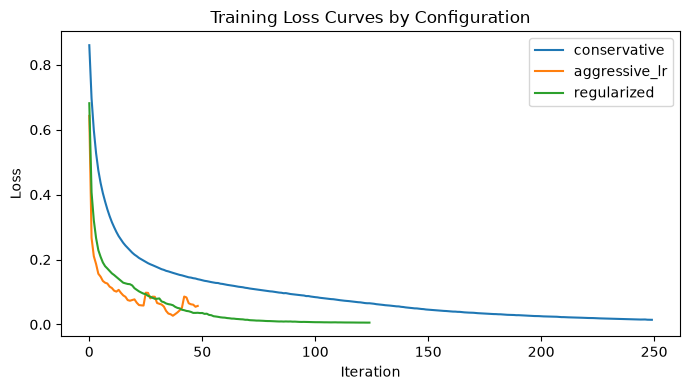

In [3]:
plt.figure(figsize=(7, 4))
for name, loss_curve in curves.items():
    plt.plot(loss_curve, label=name)
plt.title('Training Loss Curves by Configuration')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()


## Reusable Training Run Template
```text
Run name:
Dataset version:
Model architecture:
Hyperparameters (lr, regularization, epochs):
Baseline comparison:
Validation metrics:
Failure signals observed:
Decision (promote / iterate / rollback):
```

## Training Checklist
- [ ] Learning rate sweep completed.
- [ ] Train/validation behavior reviewed, not only final metric.
- [ ] Regularization choices justified by observed gap.
- [ ] Runtime/latency implications noted for deployment.
- [ ] Best run config and seed recorded.


## Case Studies & Exceptions
### Case 1: Divergence After Hyperparameter “Speed-Up”
A team increased LR to speed training and got unstable loss. Fix: lower LR, add warmup-like schedule, and monitor gradient norms.

### Case 2: Great Validation Accuracy, Poor Real-World Behavior
Model was selected by accuracy only; calibration and segment-level errors were ignored. Fix: include reliability metrics and slice analysis.

### Exception
For tiny datasets, highly tuned deep models may overfit quickly. Simpler models can deliver more stable outcomes.


## Interview Questions & Answers
1. **Q:** First deep-learning hyperparameter to tune?  
   **A:** Learning rate.
2. **Q:** Why monitor loss curves, not just final accuracy?  
   **A:** Curves reveal instability, underfitting, and overfitting dynamics.
3. **Q:** What does regularization parameter `alpha` do in MLPClassifier?  
   **A:** Adds L2 penalty to reduce overfitting.
4. **Q:** Why might aggressive LR hurt quality?  
   **A:** It can overshoot minima and destabilize updates.
5. **Q:** What is an operationally useful metric beyond accuracy?  
   **A:** Latency, calibration quality, or segment-specific recall.
6. **Q:** When is early stopping useful?  
   **A:** When validation performance plateaus or degrades.
7. **Q:** Why keep a baseline model?  
   **A:** To verify new complexity delivers real gain.
8. **Q:** What indicates overfitting?  
   **A:** Large train-vs-validation gap.
9. **Q:** Why track run configs explicitly?  
   **A:** To reproduce and compare experiments reliably.
10. **Q:** When to avoid deep training complexity?  
   **A:** If simpler models satisfy quality and operational constraints.
